# Weighted SBM by Variational Bayes (Aicher et al. 2015)

A companion to `hippocampal_sbm.ipynb`. It runs the **same three analyses** —
(1) a **bipartite** SBM on the efferent (HPC → partner) and afferent (partner → HPC)
connections, and (2) a **directed 79×79** SBM with the partner↔partner and HPC↔HPC
blocks zeroed out — but infers the blocks with a completely different engine:

**Mean-field variational Bayes (VB)** for the weighted stochastic block model of

> Aicher, Jacobs & Clauset (2015), *Learning latent block structure in weighted
> networks*, Journal of Complex Networks 3(2):221-248.

instead of graph-tool's MCMC + minimum-description-length (MDL). The inference code
lives in `vb_wsbm.py`; this notebook just drives it and visualizes the output.

## How the inference differs from `hippocampal_sbm.ipynb`

| | `hippocampal_sbm.ipynb` (graph-tool) | this notebook (`vb_wsbm.py`) |
|---|---|---|
| Inference | MCMC sampling + consensus | deterministic mean-field VB (coordinate ascent) |
| Block count `K` | **inferred** by MDL | **fixed per fit**; we **scan `K`** and pick the best **ELBO** |
| Objective | description length | **ELBO** = variational log-evidence (maximized) |
| Weight model | `real-exponential` | **Exponential** edge weights (matched) |
| Edge existence | Bernoulli (implicit) | explicit **Bernoulli** component |

**The model.** Each modeled ordered pair `(i, j)` is generated in two exponential-family
parts: an edge either exists (`Bernoulli(theta_{z_i,z_j})`) and, if it does, carries a
weight (`Exponential(lambda_{z_i,z_j})`). Conjugate priors `Beta`, `Gamma`, `Dirichlet`
make every VB update closed-form. The mean-field posterior `q(z) = prod_i q(z_i)` gives
each node a soft block-membership vector; we read a hard partition off its argmax.

**Choosing `K` by the ELBO.** Aicher's VB fits a *fixed* number of blocks, so — unlike
graph-tool's automatic MDL — we fit a range of `K` and keep the one with the highest ELBO.
The ELBO is a proper log-evidence: its parameter-KL terms penalize complexity, so it
peaks at a finite `K` rather than growing without bound.

**A note on Aicher's `alpha`.** Aicher balances the existence vs weight terms with a knob
`alpha in [0,1]`. That convex combination *tempers* (down-weights) the data likelihood,
which — combined with the Bayesian mixture's assignment-complexity cost — biases model
selection toward too few blocks. So for **choosing `K`** we use the **full generative
joint** (both components at full strength; `alpha=None`), which keeps the ELBO calibrated.
`alpha` remains available in `vb_wsbm.fit_vb_wsbm` for fixed-`K` topology-vs-weight
exploration.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from sklearn.metrics import adjusted_mutual_info_score

from helpers import log_weight_transform, get_feature_vectors_shared_hpc
import vb_wsbm as vb

np.random.seed(42)
SEED = 42
N_INIT = 10                      # VB random restarts per fit (best ELBO kept)

hippocampal_regions = ['DG', 'CA3', 'CA2', 'CA1v', 'CA1d', 'SUBv', 'SUBd']
HPC_SET = set(hippocampal_regions)

df_average = pd.read_csv('../data/average_connectome_data.csv', header=0, index_col=0)

# Shared-partner efferent / afferent feature blocks (7 HPC x 72 partners), as in Part 1
# of hippocampal_sbm.ipynb. df_efferent[hpc, partner] = HPC -> partner; df_afferent = partner -> HPC.
df_afferent, df_efferent = get_feature_vectors_shared_hpc()
partner_regions = list(df_efferent.columns)
eff_w = log_weight_transform(df_efferent.values)   # 7 x 72, HPC -> partner
aff_w = log_weight_transform(df_afferent.values)   # 7 x 72, partner -> HPC
print('partners:', len(partner_regions), '| efferent block', eff_w.shape, '| afferent block', aff_w.shape)


def print_blocks(z, region_names, title, order=None):
    # Readable per-block region listing (mirrors hippocampal_sbm), flagging HPC members.
    order = range(len(region_names)) if order is None else order
    print(title); print('=' * 78)
    for blk in sorted(set(int(v) for v in z)):
        members = [region_names[i] for i in order if int(z[i]) == blk]
        hpc_members = [r for r in members if r in HPC_SET]
        tag = f'   <-- contains HPC: {", ".join(hpc_members)}' if hpc_members else ''
        print(f'\nBlock b{blk}  (n = {len(members)}){tag}')
        print(textwrap.fill(', '.join(members), width=90,
                            initial_indent='    ', subsequent_indent='    '))

partners: 72 | efferent block (7, 72) | afferent block (7, 72)


---
## Part 1 — Bipartite VB-WSBM (efferent and afferent)

We embed the 7 HPC subregions and 72 shared partners in one 79-node space (HPC first),
and build a **directed** weight matrix per direction: efferent keeps only HPC → partner
edges, afferent only partner → HPC. The bipartite constraint (Aicher's analogue of Part
1's `pclabel`) is enforced two ways:

- **`allowed`**: HPC nodes may occupy blocks `[0, Kh)`, partners `[Kh, Kh + Kp)` — so no
  block ever mixes the two types.
- **`M` (modeled-pairs mask)**: only cross-type ordered pairs are modeled, i.e. a true
  bipartite likelihood.

Because a bipartite fit has *two* block counts, we scan a grid of `(Kh, Kp)` and pick the
pair with the best ELBO.

In [2]:
# 79-node bipartite embedding: HPC (type 0) first, then partners (type 1).
regions_bip = hippocampal_regions + partner_regions
node_types  = np.array([0] * 7 + [1] * len(partner_regions))
nH = 7

W_eff = np.zeros((79, 79))       # efferent: HPC i -> partner j
W_aff = np.zeros((79, 79))       # afferent: partner j -> HPC i
for i in range(7):
    for j in range(len(partner_regions)):
        if eff_w[i, j] > 0:
            W_eff[i, nH + j] = eff_w[i, j]
        if aff_w[i, j] > 0:
            W_aff[nH + j, i] = aff_w[i, j]

M_bip = vb.cross_type_pairs(node_types)     # only HPC<->partner pairs are modeled
print('efferent edges:', int((W_eff > 0).sum()), '| afferent edges:', int((W_aff > 0).sum()))


def scan_bipartite(Wdir, Kh_values, Kp_values, seed=SEED, n_init=N_INIT):
    # Fit the bipartite VB-WSBM over a (Kh, Kp) grid; return best-ELBO fit + the ELBO grid.
    grid = np.full((len(Kh_values), len(Kp_values)), np.nan)
    best = None
    for a, Kh in enumerate(Kh_values):
        for b, Kp in enumerate(Kp_values):
            allowed = vb.bipartite_allowed(node_types, Kh, Kp)
            res = vb.fit_vb_wsbm(Wdir, Kh + Kp, M=M_bip, allowed=allowed,
                                 n_init=n_init, seed=seed)
            grid[a, b] = res['elbo']
            if best is None or res['elbo'] > best['elbo']:
                best = {'Kh': Kh, 'Kp': Kp, 'res': res, 'elbo': res['elbo']}
    grid_df = pd.DataFrame(grid, index=[f'Kh={k}' for k in Kh_values],
                           columns=[f'Kp={k}' for k in Kp_values])
    return best, grid_df


def plot_elbo_grid(grid_df, best, title):
    plt.figure(figsize=(8, 4.5))
    ax = sns.heatmap(grid_df, annot=True, fmt='.0f', cmap='viridis',
                     cbar_kws={'label': 'ELBO'})
    bi = list(grid_df.index).index(f'Kh={best["Kh"]}')
    bj = list(grid_df.columns).index(f'Kp={best["Kp"]}')
    ax.add_patch(plt.Rectangle((bj, bi), 1, 1, fill=False, edgecolor='red', lw=3))
    ax.set_title(f'{title}\nbest (Kh, Kp) = ({best["Kh"]}, {best["Kp"]})  [red]')
    plt.tight_layout(); plt.show()

Kh_values = range(1, 5)          # <= 7 HPC nodes, so a few blocks at most
Kp_values = range(1, 9)

efferent edges: 185 | afferent edges: 231


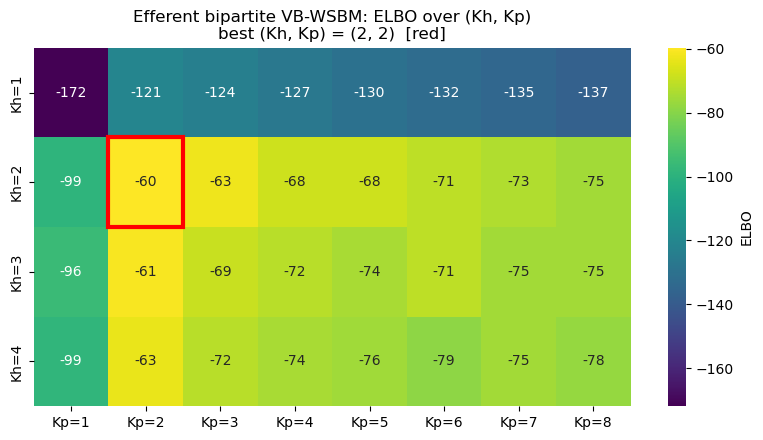

efferent: 2 HPC-blocks, 2 partner-blocks


In [3]:
best_eff, grid_eff = scan_bipartite(W_eff, Kh_values, Kp_values)
plot_elbo_grid(grid_eff, best_eff, 'Efferent bipartite VB-WSBM: ELBO over (Kh, Kp)')
z_eff = best_eff['res']['z']
print('efferent: %d HPC-blocks, %d partner-blocks'
      % (len(np.unique(z_eff[:nH])), len(np.unique(z_eff[nH:]))))

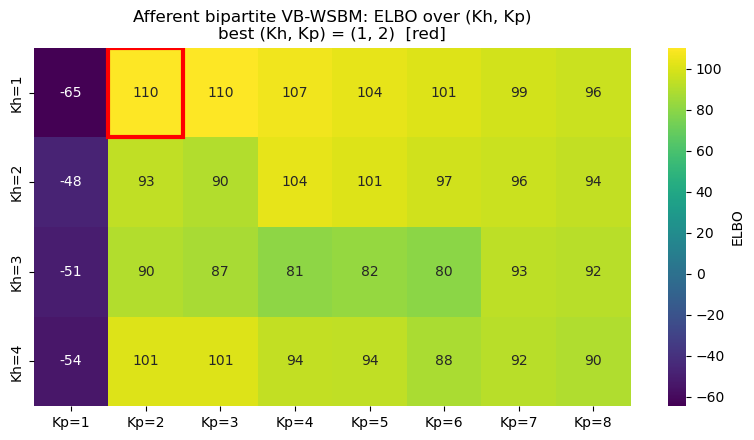

afferent: 1 HPC-blocks, 2 partner-blocks


In [4]:
best_aff, grid_aff = scan_bipartite(W_aff, Kh_values, Kp_values)
plot_elbo_grid(grid_aff, best_aff, 'Afferent bipartite VB-WSBM: ELBO over (Kh, Kp)')
z_aff = best_aff['res']['z']
print('afferent: %d HPC-blocks, %d partner-blocks'
      % (len(np.unique(z_aff[:nH])), len(np.unique(z_aff[nH:]))))

### Block-affinity matrices

As in `hippocampal_sbm.ipynb`, we summarize each fit with a **(HPC-block × partner-block)**
affinity `omega` — the all-cells mean log-weight between blocks (non-edges count as 0).
For efferent this is `omega[HPC -> partner]` (what the hippocampus *sends*); for afferent
`omega[partner -> HPC]` (what it *receives*).

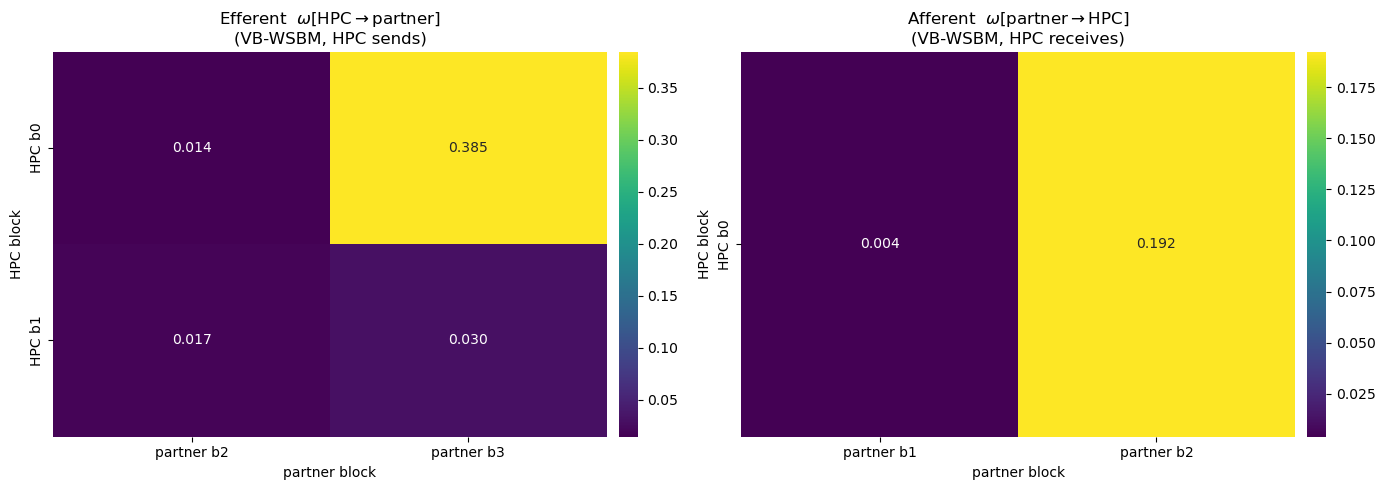

In [5]:
def hpc_partner_omega(W, z, source_is_hpc):
    # Mean weight between HPC-blocks and partner-blocks. If source_is_hpc, rows are the
    # HPC (source) blocks and cols the partner (target) blocks (efferent); the weights are
    # taken FROM source TO target. Afferent passes source_is_hpc=False and we transpose so
    # HPC stays on the rows for a like-for-like display.
    zh, zp = z[:nH], z[nH:]
    hblocks, pblocks = sorted(set(zh)), sorted(set(zp))
    hidx = [np.where(z == b)[0] for b in hblocks]       # HPC node indices per HPC-block
    pidx = [np.where(z == b)[0] for b in pblocks]       # partner node indices per partner-block
    om = np.zeros((len(hblocks), len(pblocks)))
    for a in range(len(hblocks)):
        for b in range(len(pblocks)):
            rows, cols = (hidx[a], pidx[b]) if source_is_hpc else (pidx[b], hidx[a])
            om[a, b] = W[np.ix_(rows, cols)].mean()
    return pd.DataFrame(om, index=[f'HPC b{b}' for b in hblocks],
                        columns=[f'partner b{b}' for b in pblocks])

om_eff = hpc_partner_omega(W_eff, z_eff, source_is_hpc=True)
om_aff = hpc_partner_omega(W_aff, z_aff, source_is_hpc=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(om_eff, annot=True, fmt='.3f', cmap='viridis', ax=axes[0],
            cbar_kws={'fraction': 0.045, 'pad': 0.02})
axes[0].set_title('Efferent  ' r'$\omega[\mathrm{HPC}\to\mathrm{partner}]$' '\n(VB-WSBM, HPC sends)')
axes[0].set_xlabel('partner block'); axes[0].set_ylabel('HPC block')
sns.heatmap(om_aff, annot=True, fmt='.3f', cmap='viridis', ax=axes[1],
            cbar_kws={'fraction': 0.045, 'pad': 0.02})
axes[1].set_title('Afferent  ' r'$\omega[\mathrm{partner}\to\mathrm{HPC}]$' '\n(VB-WSBM, HPC receives)')
axes[1].set_xlabel('partner block'); axes[1].set_ylabel('HPC block')
plt.tight_layout(); plt.show()

In [6]:
# Per-block region listings for both bipartite fits.
print_blocks(z_eff, regions_bip, 'EFFERENT bipartite VB-WSBM  -  regions per block')
print('\n')
print_blocks(z_aff, regions_bip, 'AFFERENT bipartite VB-WSBM  -  regions per block')

# Do partners group the same way regardless of direction? (as in hippocampal_sbm Part 1)
ami = adjusted_mutual_info_score(z_eff[nH:], z_aff[nH:])
print(f'\nAMI(efferent partner-grouping, afferent partner-grouping) = {ami:.3f}')

EFFERENT bipartite VB-WSBM  -  regions per block

Block b0  (n = 2)   <-- contains HPC: CA1v, SUBv
    CA1v, SUBv

Block b1  (n = 5)   <-- contains HPC: DG, CA3, CA2, CA1d, SUBd
    DG, CA3, CA2, CA1d, SUBd

Block b2  (n = 54)
    SI, MS, NDB, BSTam, BSTju, BSTpr, BSTif, BSTtr, BSTd, LSr.m.d, LSc.v, LSc.d, SF, AAA,
    MEAad, MEApv, MEApd, PAA, PRE, POST, RSPv.a, RSPv.b/c, RSPd, AIv, PERI, ECT, BLAa,
    BLAp, LA, PA, EPv, EPd, ADP, DMHa, DMHp, DMHv, PH, MPNm, AHNc, VMHa, PMv, TM, SUMm,
    SUMl, RCH, LHAa, LHAsfa, REc, PT, AV, AMd, IAM, SMT, VTA

Block b3  (n = 18)
    LSr.m.v, LSr.vl, LSr.dl, LSv, COApm, COApl, TR, PAR, ENTm, ENTl, ILA, BMAa, BMAp,
    AHNp, LHAjvv, LHAjd, REr, PVT


AFFERENT bipartite VB-WSBM  -  regions per block

Block b0  (n = 7)   <-- contains HPC: DG, CA3, CA2, CA1v, CA1d, SUBv, SUBd
    DG, CA3, CA2, CA1v, CA1d, SUBv, SUBd

Block b1  (n = 58)
    SI, NDB, BSTam, BSTju, BSTpr, BSTif, BSTtr, BSTd, LSr.m.v, LSr.m.d, LSr.vl, LSr.dl,
    LSc.v, LSc.d, LSv, SF, AAA,

**Reading Part 1.** A low AMI means partner regions cluster differently depending on
whether you look at what the hippocampus *sends* them vs *receives* from them — the same
send-vs-receive asymmetry signal `hippocampal_sbm.ipynb` reported with graph-tool. The
`omega` heatmaps show which partner-blocks each HPC-block couples to most strongly in
each direction.

---
## Part 2 — Directed 79×79 VB-WSBM (partner↔partner and HPC↔HPC zeroed)

Now the primary analysis: the same masked, directed 79-node network as Part 2 of
`hippocampal_sbm.ipynb` — 72 bidirectional partners + 7 HPC subregions, with
partner↔partner and HPC↔HPC edges set to 0 — but fit by VB. All ordered pairs are modeled
(default mask), so the zeroed blocks appear as genuine low-density regions. We scan `K`
and select by ELBO.

79x79 matrix: (79, 79) | non-zero entries: 416


ELBO-selected K = 4 | blocks actually used = 4


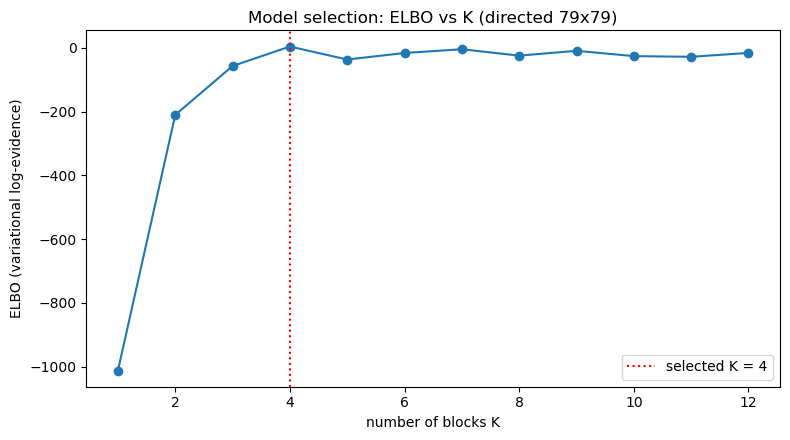

In [7]:
regions_79 = partner_regions + hippocampal_regions        # match hippocampal_sbm ordering
sub = df_average.loc[regions_79, regions_79].copy().fillna(0.0)
sub.loc[partner_regions, partner_regions] = 0.0           # zero partner<->partner
sub.loc[hippocampal_regions, hippocampal_regions] = 0.0   # zero HPC<->HPC
W79 = log_weight_transform(sub.values)                    # ordinal -> log-weight, directed
print('79x79 matrix:', W79.shape, '| non-zero entries:', int((W79 > 0).sum()))

scan79 = vb.select_K(W79, range(1, 13), n_init=N_INIT, seed=SEED)
best_K = scan79['best_K']
z79 = scan79['best']['z']
print('ELBO-selected K =', best_K, '| blocks actually used =', scan79['best']['n_blocks_used'])

Ks = list(scan79['elbos'].keys())
plt.figure(figsize=(8, 4.5))
plt.plot(Ks, [scan79['elbos'][k] for k in Ks], 'o-')
plt.axvline(best_K, color='red', ls=':', label=f'selected K = {best_K}')
plt.xlabel('number of blocks K'); plt.ylabel('ELBO (variational log-evidence)')
plt.title('Model selection: ELBO vs K (directed 79x79)')
plt.legend(); plt.tight_layout(); plt.show()

HPC subregions fall in block(s): [1, 2]


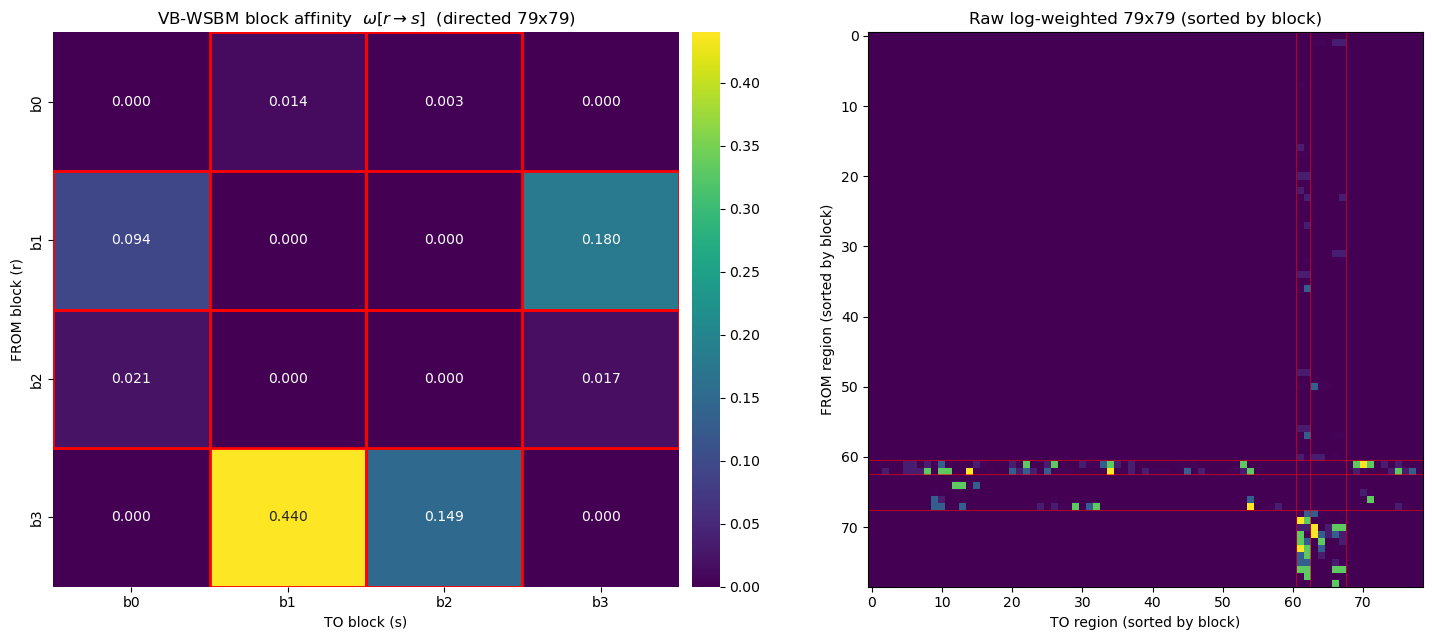

In [8]:
# Block-affinity omega + block-sorted adjacency, as in hippocampal_sbm Part 2.
omega79, block_ids = vb.block_affinity(W79, z79)
binv = np.array([block_ids.index(int(b)) for b in z79])
hpc_block_ids = sorted(set(int(z79[i]) for i, r in enumerate(regions_79) if r in HPC_SET))
print('HPC subregions fall in block(s):', hpc_block_ids)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
sns.heatmap(omega79, annot=True, fmt='.3f', cmap='viridis', ax=axes[0],
            xticklabels=[f'b{b}' for b in block_ids], yticklabels=[f'b{b}' for b in block_ids],
            cbar_kws={'fraction': 0.045, 'pad': 0.02})
axes[0].set_xlabel('TO block (s)'); axes[0].set_ylabel('FROM block (r)')
axes[0].set_title(r'VB-WSBM block affinity  $\omega[r \to s]$  (directed 79x79)')
for hp in [block_ids.index(h) for h in hpc_block_ids]:
    axes[0].add_patch(plt.Rectangle((0, hp), len(block_ids), 1, fill=False, edgecolor='red', lw=2))
    axes[0].add_patch(plt.Rectangle((hp, 0), 1, len(block_ids), fill=False, edgecolor='red', lw=2))

order = np.argsort(binv, kind='stable')
W_sorted = W79[np.ix_(order, order)]
bounds = np.where(np.diff(binv[order]) != 0)[0] + 1
axes[1].imshow(W_sorted, cmap='viridis', vmin=0, vmax=float(W79.max()), aspect='equal')
axes[1].set_title('Raw log-weighted 79x79 (sorted by block)')
axes[1].set_xlabel('TO region (sorted by block)'); axes[1].set_ylabel('FROM region (sorted by block)')
for b in bounds:
    axes[1].axhline(b - 0.5, color='red', lw=0.6, alpha=0.7)
    axes[1].axvline(b - 0.5, color='red', lw=0.6, alpha=0.7)
plt.tight_layout(); plt.show()

In [9]:
print_blocks(z79, regions_79,
             f'Regions per block  (VB-WSBM, K = {len(block_ids)}, 79 regions)')

Regions per block  (VB-WSBM, K = 4, 79 regions)

Block b0  (n = 61)
    SI, NDB, BSTam, BSTju, BSTpr, BSTif, BSTtr, BSTd, LSr.m.v, LSr.m.d, LSr.vl, LSr.dl,
    LSc.v, LSc.d, LSv, SF, AAA, MEAad, MEApv, MEApd, COApl, PAA, TR, PRE, POST, PAR, ILA,
    RSPv.a, RSPv.b/c, RSPd, AIv, PERI, ECT, BMAa, BMAp, BLAa, EPv, EPd, ADP, DMHa, DMHp,
    DMHv, PH, MPNm, AHNc, AHNp, VMHa, PMv, TM, SUMm, SUMl, RCH, LHAa, LHAjvv, LHAjd,
    LHAsfa, PT, AV, IAM, SMT, VTA

Block b1  (n = 2)   <-- contains HPC: CA1v, SUBv
    CA1v, SUBv

Block b2  (n = 5)   <-- contains HPC: DG, CA3, CA2, CA1d, SUBd
    DG, CA3, CA2, CA1d, SUBd

Block b3  (n = 11)
    MS, COApm, ENTm, ENTl, BLAp, LA, PA, REr, REc, PVT, AMd


### Follow-up: separating block-pair *density* from *edge-mean*

The affinity `omega` used above conflates two things:

$$\omega_{rs} \;=\; \rho_{rs}\,\cdot\,\hat{\mu}_{rs}$$

- $\rho_{rs}$ = block-pair **density** = fraction of $(i \in r,\, j \in s)$ ordered pairs
  that actually have an edge.
- $\hat{\mu}_{rs}$ = block-pair **edge-mean** = mean log-weight averaged **over the edges
  that exist only**.

A small $\omega_{rs}$ can mean low density, low edge strength, or both — and those are
different biological claims. For the hippocampus:

- $\rho[\mathrm{HPC} \to s]$ low ⇒ the hippocampus *rarely* projects to block $s$ (few targets).
- $\hat{\mu}[\mathrm{HPC} \to s]$ low ⇒ when it does project there, the projections are *weak*.

The cell below plots all three matrices side-by-side and breaks the HPC send/receive
profile out by density vs edge-mean. (This mirrors the same follow-up in
`hippocampal_sbm.ipynb`; the direction-flip permutation test there is intentionally
omitted here.)

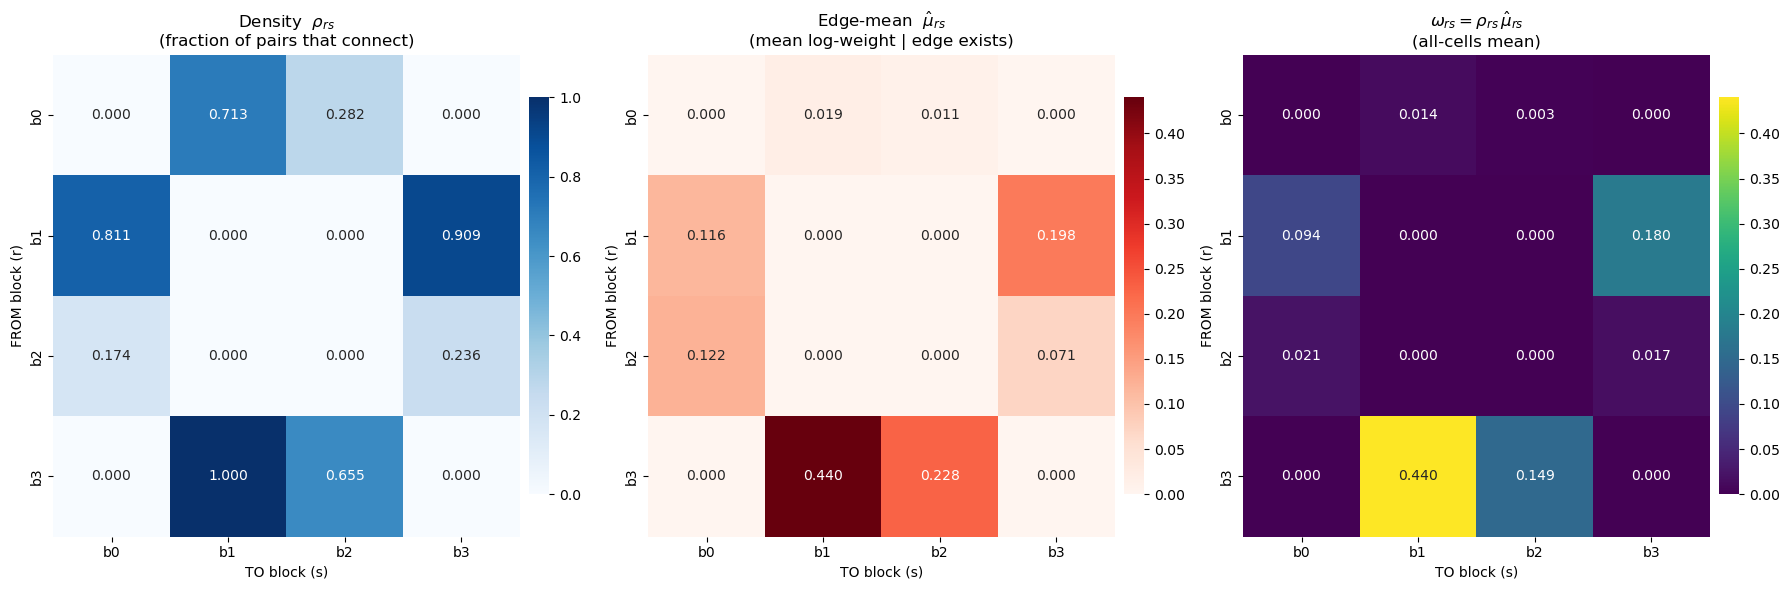

=== HPC block b1 ===
    send rho (HPC->s)  send mu  (HPC->s)  recv rho (s->HPC)  recv mu  (s->HPC)
b0             0.8115             0.1157             0.7131             0.0192
b1             0.0000             0.0000             0.0000             0.0000
b2             0.0000             0.0000             0.0000             0.0000
b3             0.9091             0.1979             1.0000             0.4400

=== HPC block b2 ===
    send rho (HPC->s)  send mu  (HPC->s)  recv rho (s->HPC)  recv mu  (s->HPC)
b0             0.1738             0.1221             0.2820             0.0109
b1             0.0000             0.0000             0.0000             0.0000
b2             0.0000             0.0000             0.0000             0.0000
b3             0.2364             0.0714             0.6545             0.2278



In [10]:
# Decompose omega[r,s] = rho[r,s] * mu_hat[r,s]  (density * edge-mean), on the VB partition.
B = len(block_ids)
rho    = np.zeros((B, B))
mu_hat = np.zeros((B, B))
for r in range(B):
    rmask = binv == r
    for s in range(B):
        cell = W79[np.ix_(rmask, binv == s)]
        edges = cell > 0
        rho[r, s]    = edges.mean()
        mu_hat[r, s] = cell[edges].mean() if edges.any() else 0.0

# Sanity check: rho * mu_hat should reproduce the all-cells omega used above.
assert np.allclose(rho * mu_hat, omega79, atol=1e-10), 'decomposition mismatch'

labels = [f'b{b}' for b in block_ids]
panels = [
    (rho,    r'Density  $\rho_{rs}$' '\n' r'(fraction of pairs that connect)',        'Blues'),
    (mu_hat, r'Edge-mean  $\hat{\mu}_{rs}$' '\n' r'(mean log-weight | edge exists)',   'Reds'),
    (omega79, r'$\omega_{rs} = \rho_{rs}\,\hat{\mu}_{rs}$' '\n' r'(all-cells mean)',    'viridis'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (Mx, title, cmap) in zip(axes, panels):
    sns.heatmap(Mx, annot=True, fmt='.3f', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax,
                cbar_kws={'fraction': 0.04, 'pad': 0.02})
    ax.set_title(title); ax.set_xlabel('TO block (s)'); ax.set_ylabel('FROM block (r)')
plt.tight_layout(); plt.show()

# HPC send/receive profile broken out by density vs edge-mean.
for hb in hpc_block_ids:
    bi = block_ids.index(hb)
    tbl = pd.DataFrame({
        'send rho (HPC->s)': rho[bi, :],
        'send mu  (HPC->s)': mu_hat[bi, :],
        'recv rho (s->HPC)': rho[:, bi],
        'recv mu  (s->HPC)': mu_hat[:, bi],
    }, index=labels)
    print(f'=== HPC block b{hb} ===')
    print(tbl.round(4).to_string())
    print()

---
## Summary and comparison to `hippocampal_sbm.ipynb`

- **Same three analyses, different inference.** Bipartite efferent/afferent + masked
  directed 79×79, but fit by Aicher-style mean-field **variational Bayes** with the block
  count chosen by **ELBO** rather than graph-tool's MCMC + MDL.
- **What to compare.** (1) Do the two engines infer similar block *counts*? VB-with-ELBO
  tends to be **more conservative** (fewer blocks) than MDL/MCMC. (2) Do the HPC subregions
  land in the same groupings? (3) Is the efferent-vs-afferent partner AMI low under both
  methods (the send/receive-asymmetry signal)?
- **Caveats.**
  - VB is non-convex; we mitigate local optima with a k-means warm start + random restarts
    (`N_INIT`), keeping the best ELBO. Results can still shift with `SEED`/`N_INIT`.
  - The Exponential weight model and the log-weight transform are modeling choices shared
    with the graph-tool notebook, not the only defensible ones.
  - ELBO model selection uses the untempered joint likelihood (`alpha=None`); switching to
    Aicher's tempered `alpha` changes the selected `K`.